<center><h2>EXAMEN 1 (exemple) SUR MACHINE DE DATA SCIENCE (2024-2025)</h2></center>

Epreuve sans documents (hors Campus et référence aux bibliothèques). Tous objets connectés interdits.

L'objectif de cette évaluation est de valider votre capacité à réaliser des traitements standards sur des données pour : 
- manipuler un ensemble de données (gérer des valeurs manquantes, des valeurs aberrantes) ;
- analyser et visualiser les variables de cet ensemble ;
- mettre en évidence des variables susceptibles d'être pertinentes pour une application donnée ;
- mettre en forme les données pour construire des modèles de régression ou de classification (dans un contexte supervisé) ;
- évaluer et interpréter les modèles.

L'épreuve se déroule sur jupyter notebook

Vous disposez des différents documents vus en cours sur le campus https://campus.eseo.fr/ ainsi que les références aux bibliothèques. Tout autre document est interdit.

**Vous devez impérativement renommer votre script (.ipynb) avec le nommage suivant~: NOM_PRENOM__DS.ipynb** 
    
**Votre programme doit s'exécuter sans erreur et afficher les figures demandées.**

**Certaines questions amènent à commenter votre réponse. Pour autant, le code développé pour répondre à la question doit impérativement être présent ; le commentaire seul n'est pas considéré comme une réponse acceptable.**

**Vous ne devez pas changer le nom de la base de données.**

<center><h3>Description de la base de données</h3></center>

L'objectif est de prédire le temps de course d'un athlète sur 10 km `temps_10k`. Les variables à notre disposition sont :
- `km_sem` : nombre de km/semaine (en km) ;
- `heur_som`: nombre d'heure de sommeil par jour (en heure) ;
- `age` : age (en année) ;
- `poids` : poids (en kg) ;
- `temps_10k` : **variable quantitative à prédire** : temps réalisé pour chaque athlète sur 10 km (en minute)

Note : les données présentées ne proviennent pas de mesures réelles, elles ont été générées de manière synthétique.

In [57]:
# Bibliothèque
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error , r2_score


In [7]:
# Charger les données
df = pd.read_csv('donnees_pred_temps_10km.csv', sep=',')

### Dans cette première l'objectif est d'extraire de l'information entre les variables explicatives (variables d'entrée potentielles du modèle : `km_sem`, `heur_som`, `age`, `poids`) et la variable à prédire (`temps_10k`).

**1) Quelles sont les statistiques qui décrivent la variable à prédire `temps_10k` (min, max, médiane) ?** [1 point]

In [31]:
# développer votre code pour répondre à la question
print(df.describe())


          km_sem    heur_som         age       poids   temps_10k
count  200.00000  200.000000  200.000000  200.000000  200.000000
mean    34.76950    7.252500   44.300000   71.640000   78.981500
std     13.92386    2.000878   35.746174   11.515792   17.586616
min     10.20000    4.000000   18.000000   50.000000   43.400000
25%     22.85000    5.600000   29.000000   61.000000   65.100000
50%     35.25000    6.900000   42.500000   73.000000   77.450000
75%     46.07500    9.125000   54.250000   81.000000   90.800000
max     59.70000   10.900000  480.000000   90.000000  120.900000


**2) Visualiser la distribution (nuage de points) entre la variable à prédire `temps_10k` et chacune des 4 variables explicatives (variables d'entrée potentielles du modèle : `km_sem`, `heur_som`, `age`, `poids`). Commenter.** \[2 points\]

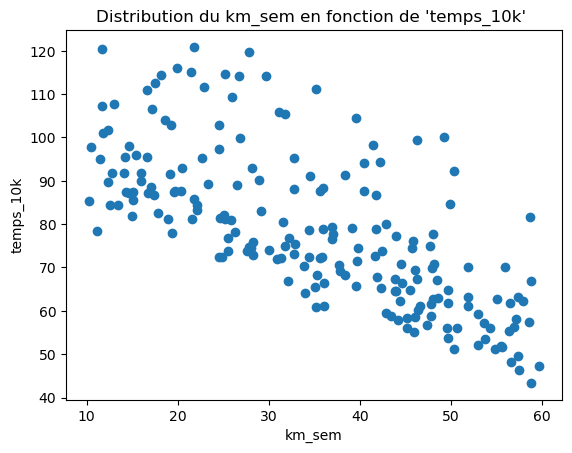

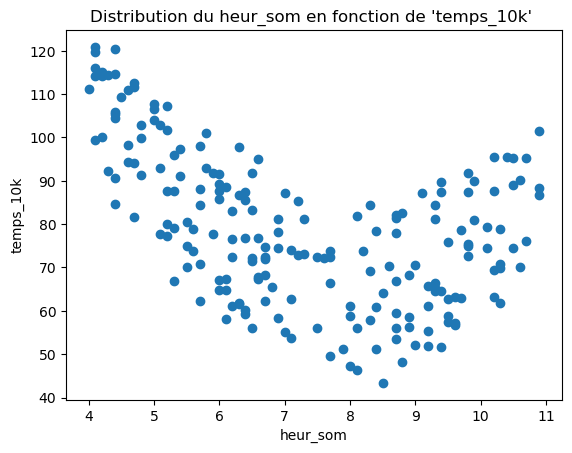

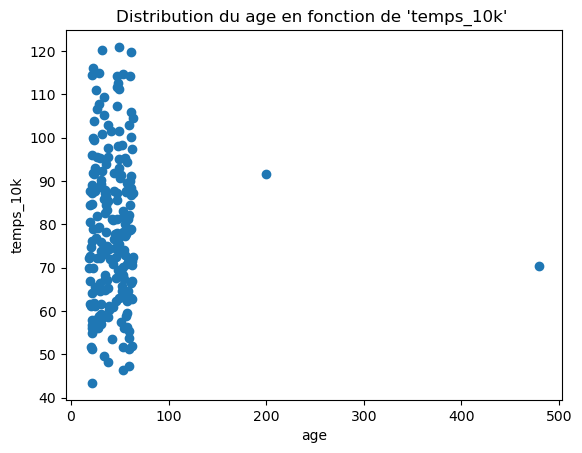

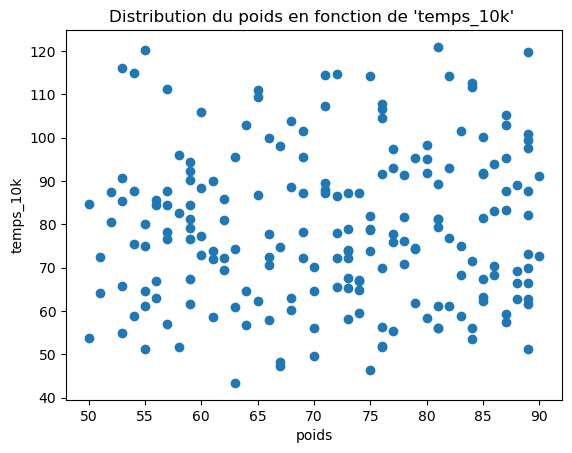

In [16]:
# développer votre code pour répondre à la question
expli = ['km_sem', 'heur_som', 'age', 'poids']
for var in expli : 
    plt.scatter(df[var], df['temps_10k'])
    plt.title(f"Distribution du {var} en fonction de 'temps_10k' ")
    plt.xlabel(var)
    plt.ylabel('temps_10k')
    plt.show()

**3) Pour chacune des 4 variables explicatives (`km_sem`, `heur_som`, `age`, `poids`), déterminer numériquement son lien linéaire avec la vairable à prédire `temps_10k`. Commenter.** \[2 points\]

In [18]:
# développer votre code pour répondre à la question
print(df.corr(numeric_only = True)['temps_10k'])

km_sem      -0.714215
heur_som    -0.498437
age         -0.005260
poids        0.037843
temps_10k    1.000000
Name: temps_10k, dtype: float64


**4) Analyser l'ensemble de données pour détecter d'éventuelles valeurs manquantes, aberrantes ou incohérentes, puis effectuer un nettoyage approprié. Décriver dans le cadre (ci-dessous) les éléments détectés et expliquer votre traitement.** \[2 points\]

In [39]:
# développer votre code pour répondre à la question
df.describe()
quant = ['km_sem', 'heur_som', 'age', 'poids','temps_10k']
for c in quant : df[c] = df[c].fillna(df[c].median()) 

  
print(df[df['age']> 90])
df = df.drop(df[df['age'] >90].index)
print(df.isnull().sum())
df.describe()

Empty DataFrame
Columns: [km_sem, heur_som, age, poids, temps_10k]
Index: []
km_sem       0
heur_som     0
age          0
poids        0
temps_10k    0
dtype: int64


,km_sem,heur_som,age,poids,temps_10k
count,198.00000,198.000000,198.000000,198.000000,198.000000
mean,34.85303,7.252020,41.313131,71.545455,78.961616
std,13.94937,2.006733,13.968163,11.524217,17.641933
min,10.20000,4.000000,18.000000,50.000000,43.400000
25%,23.00000,5.600000,29.000000,61.000000,64.900000
50%,35.27500,6.900000,42.000000,73.000000,77.450000
75%,46.22500,9.175000,54.000000,81.000000,90.550000
max,59.70000,10.900000,63.000000,90.000000,120.900000


### Dans cette seconde partie, l'objectif est de construire un modèle sur la base de l'analyse réalisée dans la partie précédente. Pour autant, si vous n'avez pas pu réaliser les questions précédentes, vous pouvez considérer la variable d'entrée comme étant `heur_som` : X = df[['heur_som']]

**5) Sur la base des questions 2 et 3, choisir une variable d'entrée pour construire un modèle de régression afin de prédire la variable `temps_10k`. Une variable `X` contiendra cette variable d'entrée et la variable `Y` la variable de sortie (`temps_10k`). En commentaire, justifier le choix de la variable d'entrée.** \[2 points\]

In [54]:
# développer votre code pour répondre à la question
print(df.corr(numeric_only = True)['temps_10k'])
x = df[['km_sem']]
y = df['temps_10k']

km_sem      -0.709837
heur_som    -0.496511
age          0.023647
poids        0.039507
temps_10k    1.000000
Name: temps_10k, dtype: float64


**6) Préparer les données de manière à optimiser la création et l'évaluation du modèle de régression. Afin de faciliter l'interprétation du modèle, la variable de sortie ne sera pas normalisée. Justifier les traitements appliqués sur les données.** \[2 points]

In [55]:
# développer votre code pour répondre à la question
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size =0.3 , random_state = 42)

scaler = StandardScaler()

x_train_s= scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

**7) Construire un modèle de régression et évaluer quantitativement (numériquement) ses performances. Commenter la valeur de l'indicateur choisi qui vous a permis d'évaluer votre modèle.** \[3 points]

In [59]:
# développer votre code pour répondre à la question
model = LinearRegression()
model.fit(x_train_s , y_train)
y_predict = model.predict(x_test_s)

print("RMSE : ",root_mean_squared_error(y_test,y_predict))
print("R2_score :",r2_score(y_test,y_predict))

RMSE :  12.556473339214259
R2_score : 0.5189616295554595


**8) Récupérer les paramètres de la fonction de régression (`a`, `b`). Interpréter en commentaire chacun de ces paramètres.** [1 point]

In [61]:
# développer votre code pour répondre à la question
a = model.coef_[0]
b = model.intercept_
print("a : ",a ,"b : ", b)

a :  -12.168768603645571 b :  79.5789855072464


**9) Visualiser la distribution (nuage de points) entre la variable à prédire (`temps_10k`, `Y`) en fonction de la variable explicative (variable d'entrée, `X`) et superposer, dans cet espace, votre fonction de régression.** [2 points]

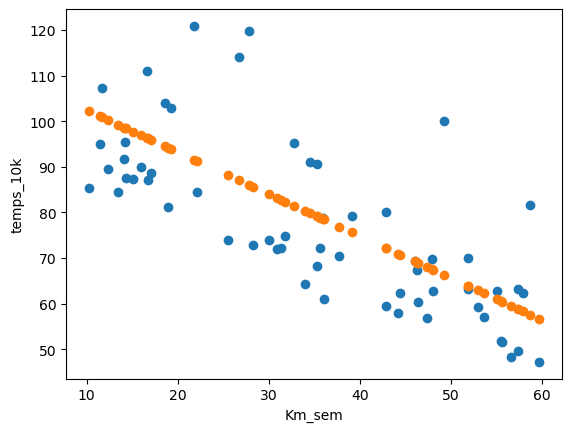

In [76]:
# développer votre code pour répondre à la question
plt.scatter(x_test,y_test)
plt.scatter(x_test,y_predict, label='Regression' )
plt.xlabel('Km_sem')
plt.ylabel('temps_10k')
plt.show()

**10) Un nouveau sportif (`df_test`) se présente défini par les paramètres ci-dessous. Quelle serait, d'après votre modèle, le temps que mettrait cet individu poru parcourir les 10 km ?** \[2 points\]


In [84]:
# définition de l'échantillon à tester
df_test = pd.DataFrame([{
    'km_sem': 34,
    'heur_som': 7,
    'age': 42,
    'poids': 70,
    'temps_10k':np.nan
}])
df_test.head()


,km_sem,heur_som,age,poids,temps_10k
0,34,7,42,70,NaN


In [83]:
# développer votre code pour répondre à la question
A_B = df_test[['km_sem']]
Norm = scaler.transform(A_B)
Prediction = model.predict(Norm)[0]
print("Prediction nouvelle",Prediction)


Prediction nouvelle 80.29649878905376


**11) A la première question, vous avez probablement dû observer une relation non linéaire entre deux variables. Pour exploiter cette variable dans un modéle alors que la relation avec la variable à prédire semble non linéaire, quelle démarche proposeriez-vous ? Il n’est pas attendu de code, uniquement une explication de la démarche.** [1 point]